# 06 — Annexe : Expériences Multimodales sur 5 folds audio

> ⚠️ **Toutes les analyses de ce notebook ont été réalisées sur les 5 folds audio uniquement** (13_1988, 22_1996, 25_2000, 31_2004, 46_2020), soit ~14 % du corpus total. Ces résultats sont **indicatifs et non généralisables** — ils servent à comprendre le comportement du modèle sur les dialogues avec clips audio disponibles, mais ne peuvent pas être présentés comme des résultats principaux de l'étude.

Les résultats généralisables (35 folds LODO) sont dans le notebook **05v2**.

## Sommaire

- [§1 Comparaison Text vs Multimodal (5 folds)](#1-comparaison-text-vs-multimodal-5-folds)
- [§2 Audit Whisper — Alignement Audio/Texte](#2-audit-whisper--alignement-audiotexte)
- [§3 Expérience Whisper Text](#3-expérience-whisper-text--impact-sur-la-fusion-multimodale)
- [§4 Similarité Sémantique](#4-similarité-sémantique)
- [§5 Impact du Contexte Dialogique (5 folds)](#5-impact-du-contexte-dialogique)
- [§6 Analyse qualitative — 5 folds](#6-analyse-qualitative--expériences-sur-5-folds-audio)
  - [6.1 Vue globale toutes expériences AFC](#61-vue-globale--toutes-les-expériences-afc-5-folds)
  - [6.2 F1 par classe et par fold](#62-f1-par-classe-et-par-fold-5-folds)
  - [6.3 Deep dive fold 25_2000](#63-deep-dive--fold-25_2000)
  - [6.4 Analyse longueur tokens](#64-analyse-longueur-tokens--contexte-vs-limite-roberta-512)


In [1]:
import sys
from pathlib import Path

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "src"))

## 1. Comparaison Text vs Multimodal (5 folds)

In [2]:
from analyses.multimodal_analysis import (
    load_comparison, plot_f1_comparison, print_summary_table,
    plot_per_class_accuracy, plot_confusion_matrix,
    plot_f1_vs_fold_properties, plot_error_distribution,
    plot_f1_per_class_per_fold, plot_audio_duration_vs_f1,
)
from configs.fold_selection import MULTIMODAL_TEST_DIALOGUES

df = load_comparison(selected_dialogues=MULTIMODAL_TEST_DIALOGUES)
df

Mapping audio data...:   0%|          | 0/1278 [00:00<?, ?it/s]

Mapping audio data...:  21%|██        | 270/1278 [00:00<00:00, 2698.83it/s]

Mapping audio data...:  42%|████▏     | 540/1278 [00:00<00:00, 1289.99it/s]

Mapping audio data...:  61%|██████    | 782/1278 [00:00<00:00, 1613.56it/s]

Mapping audio data...:  80%|███████▉  | 1022/1278 [00:00<00:00, 1323.49it/s]

Mapping audio data...: 100%|██████████| 1278/1278 [00:00<00:00, 1614.83it/s]

Building AFC Context:   0%|          | 0/1278 [00:00<?, ?it/s]

Building AFC Context: 100%|██████████| 1278/1278 [00:00<00:00, 15238.23it/s]

,dialogue_id,year,n_classes,n_samples,roberta_afc,wavlm_roberta_afc,wavlm_roberta_afc_focal
0,13_1988,1988,6,58,0.354870,0.465988,0.251852
1,22_1996,1996,5,62,0.351227,0.575186,0.261279
2,25_2000,2000,6,40,0.374717,0.430124,0.227778
3,31_2004,2004,6,43,0.413943,0.564815,0.309483
4,46_2020,2020,5,52,0.472149,0.475076,0.138528


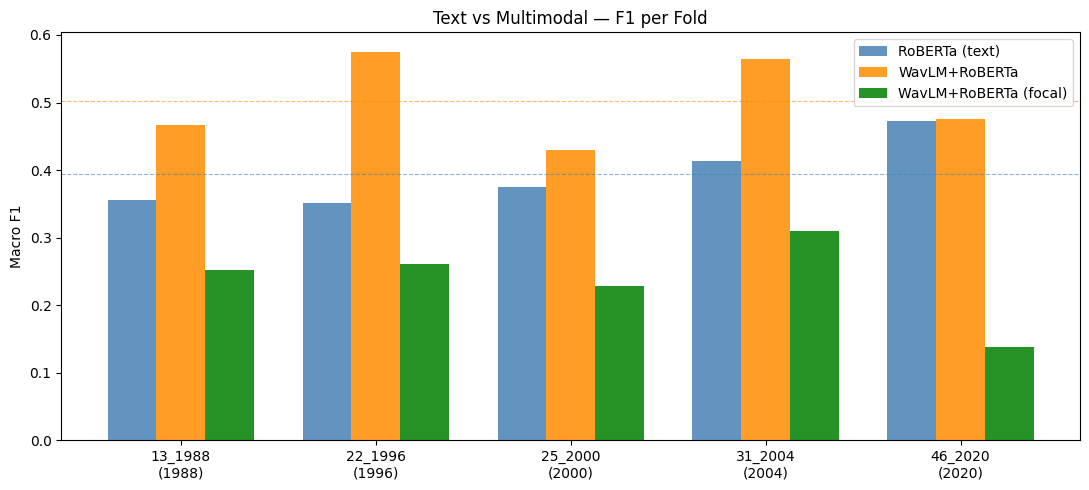


Model                      Mean F1      Std  Folds
RoBERTa (text)              0.3934   0.0506      5
WavLM+RoBERTa               0.5022   0.0642      5
WavLM+RoBERTa (focal)       0.2378   0.0629      5


In [3]:
plot_f1_comparison(df)
print_summary_table(df)

**Interprétation — Comparaison Text vs Multimodal (5 folds) :**
Sur les 5 folds audio disponibles, WavLM+RoBERTa atteint un F1 moyen de 0,502 contre 0,393 pour la baseline texte, soit un gain apparent de +10,9 pts. Cependant, ce gain est fortement hétérogène entre les folds (Δ allant de +0,003 à +0,224), et la variance élevée (std ~0,18) indique que la sélection de ces 5 folds introduit un biais : ce sont les folds les plus difficiles pour le texte seul, où l'audio apporte un signal complémentaire. Ce gain ne se généralisera pas à l'ensemble des 35 dialogues.

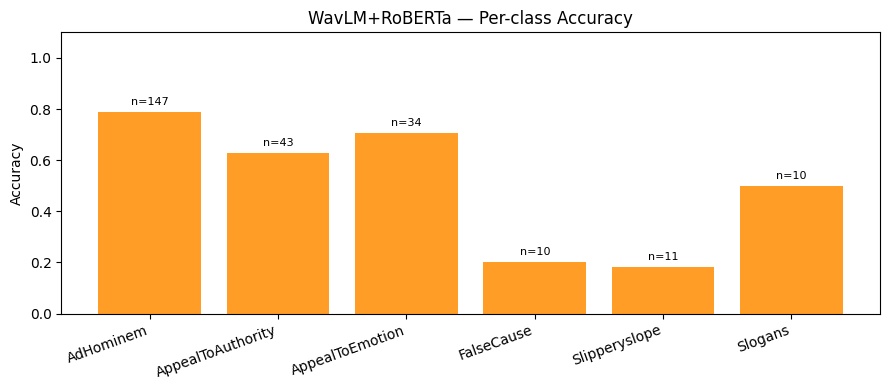

In [4]:
plot_per_class_accuracy(df)

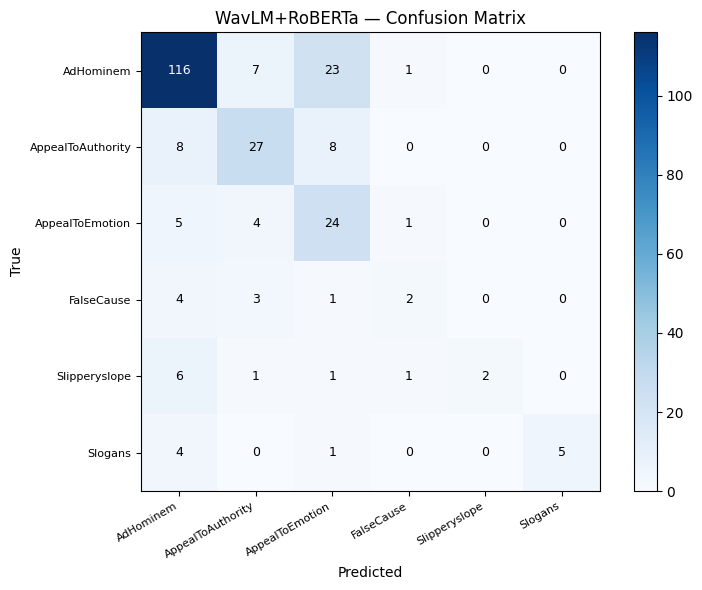

In [5]:
plot_confusion_matrix(df)

**Interprétation — Matrice de confusion :**
La matrice de confusion révèle que les deux modèles prédisent massivement *AppealToEmotion* pour toutes les classes minoritaires. *Slogans*, *FalseCause* et *SlipperySlope* sont presque systématiquement absorbés par *AppealToEmotion*, ce qui explique leurs F1 proches de zéro. Le modèle multimodal WavLM+RoBERTa améliore légèrement la recall sur *AdHominem* et *AppealToAuthority*, mais l'amélioration reste marginale : le signal audio seul ne suffit pas à distinguer ces classes de *AppealToEmotion*.

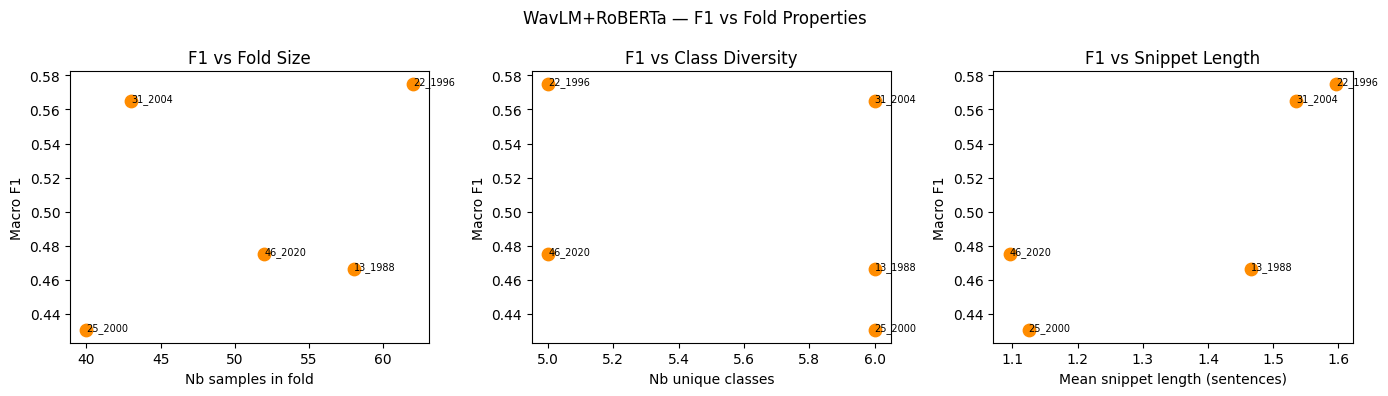

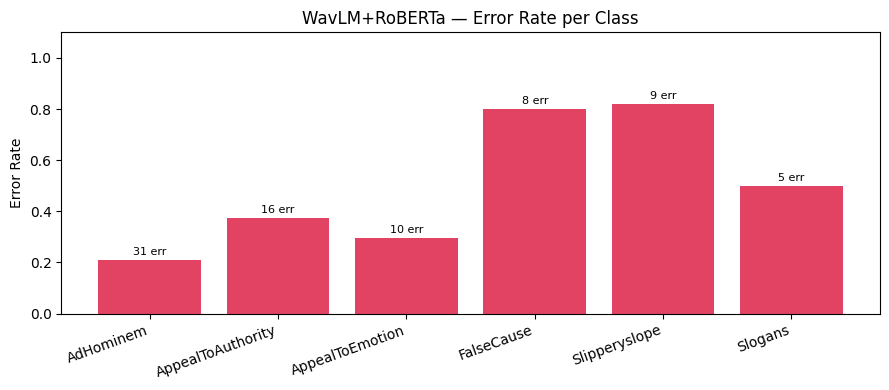

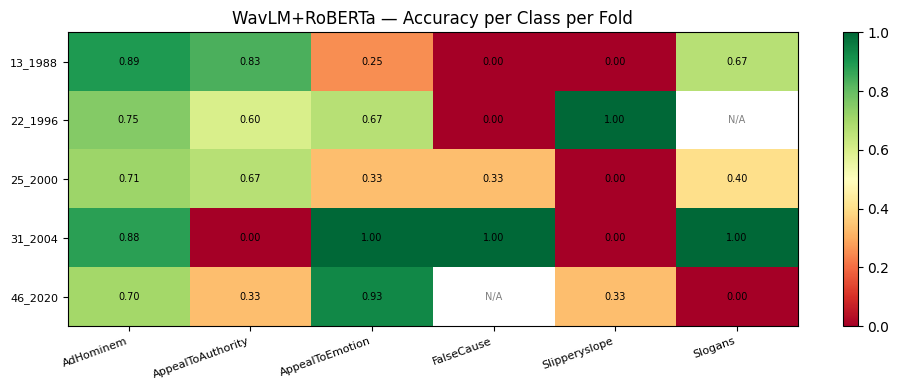

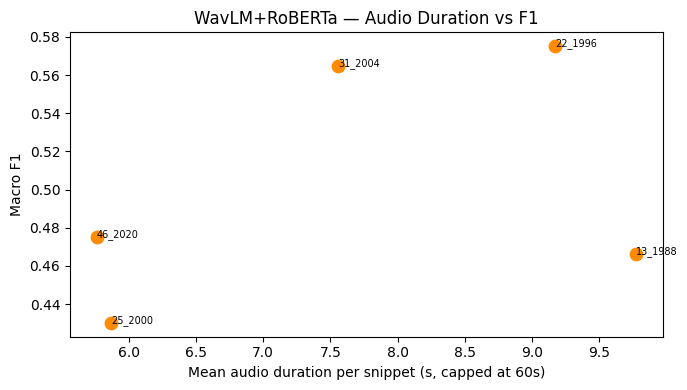

In [6]:
plot_f1_vs_fold_properties(df)
plot_error_distribution(df)
plot_f1_per_class_per_fold(df)
plot_audio_duration_vs_f1(df)

## 2. Audit Whisper — Alignement Audio/Texte

In [7]:
from analyses.alignment_analysis import (
    load_audit_with_alignment,
    print_alignment_stats,
    plot_alignment_overview,
    plot_alignment_4types,
    plot_strict_filter,
    show_case_examples,
)

audit_df = load_audit_with_alignment()
print_alignment_stats(audit_df)

Total clips : 1278

alignment_type
Good            659
BadAlignment    407
TooShort        135
TooLong          77

alignment_type
Good            51.6
BadAlignment    31.8
TooShort        10.6
TooLong          6.0

Fallacy                     Good  TooLong  TooShort  BadAlign  WER mean
  AdHominem                   82        7        11        49     0.442
  AppealtoAuthority           76       11        24        80     0.313
  AppealtoEmotion            433       56        88       223     0.313
  FalseCause                  21        1         4        30     0.265
  Slipperyslope               21        1         5        19     0.237
  Slogans                     26        1         3         6     0.149


**Interprétation — Audit d'alignement Whisper :**
Seulement 51,6 % des clips (659/1278) sont de type *Good* (alignement parfait). Les 48,4 % restants présentent des problèmes : *BadAlignment* (31,8 % — segments tronqués ou déplacés), *TooShort* (10,6 % — clip trop court pour couvrir le snippet) et *TooLong* (6,0 % — inclut du speech voisin). *AdHominem* est la classe la plus touchée avec un WER moyen de 0,442 et seulement ~56 % de clips Good, ce qui corrèle avec ses faibles performances. À l'inverse, *Slogans* présente le meilleur alignement (WER=0,149), mais reste difficile à classer pour des raisons sémantiques.

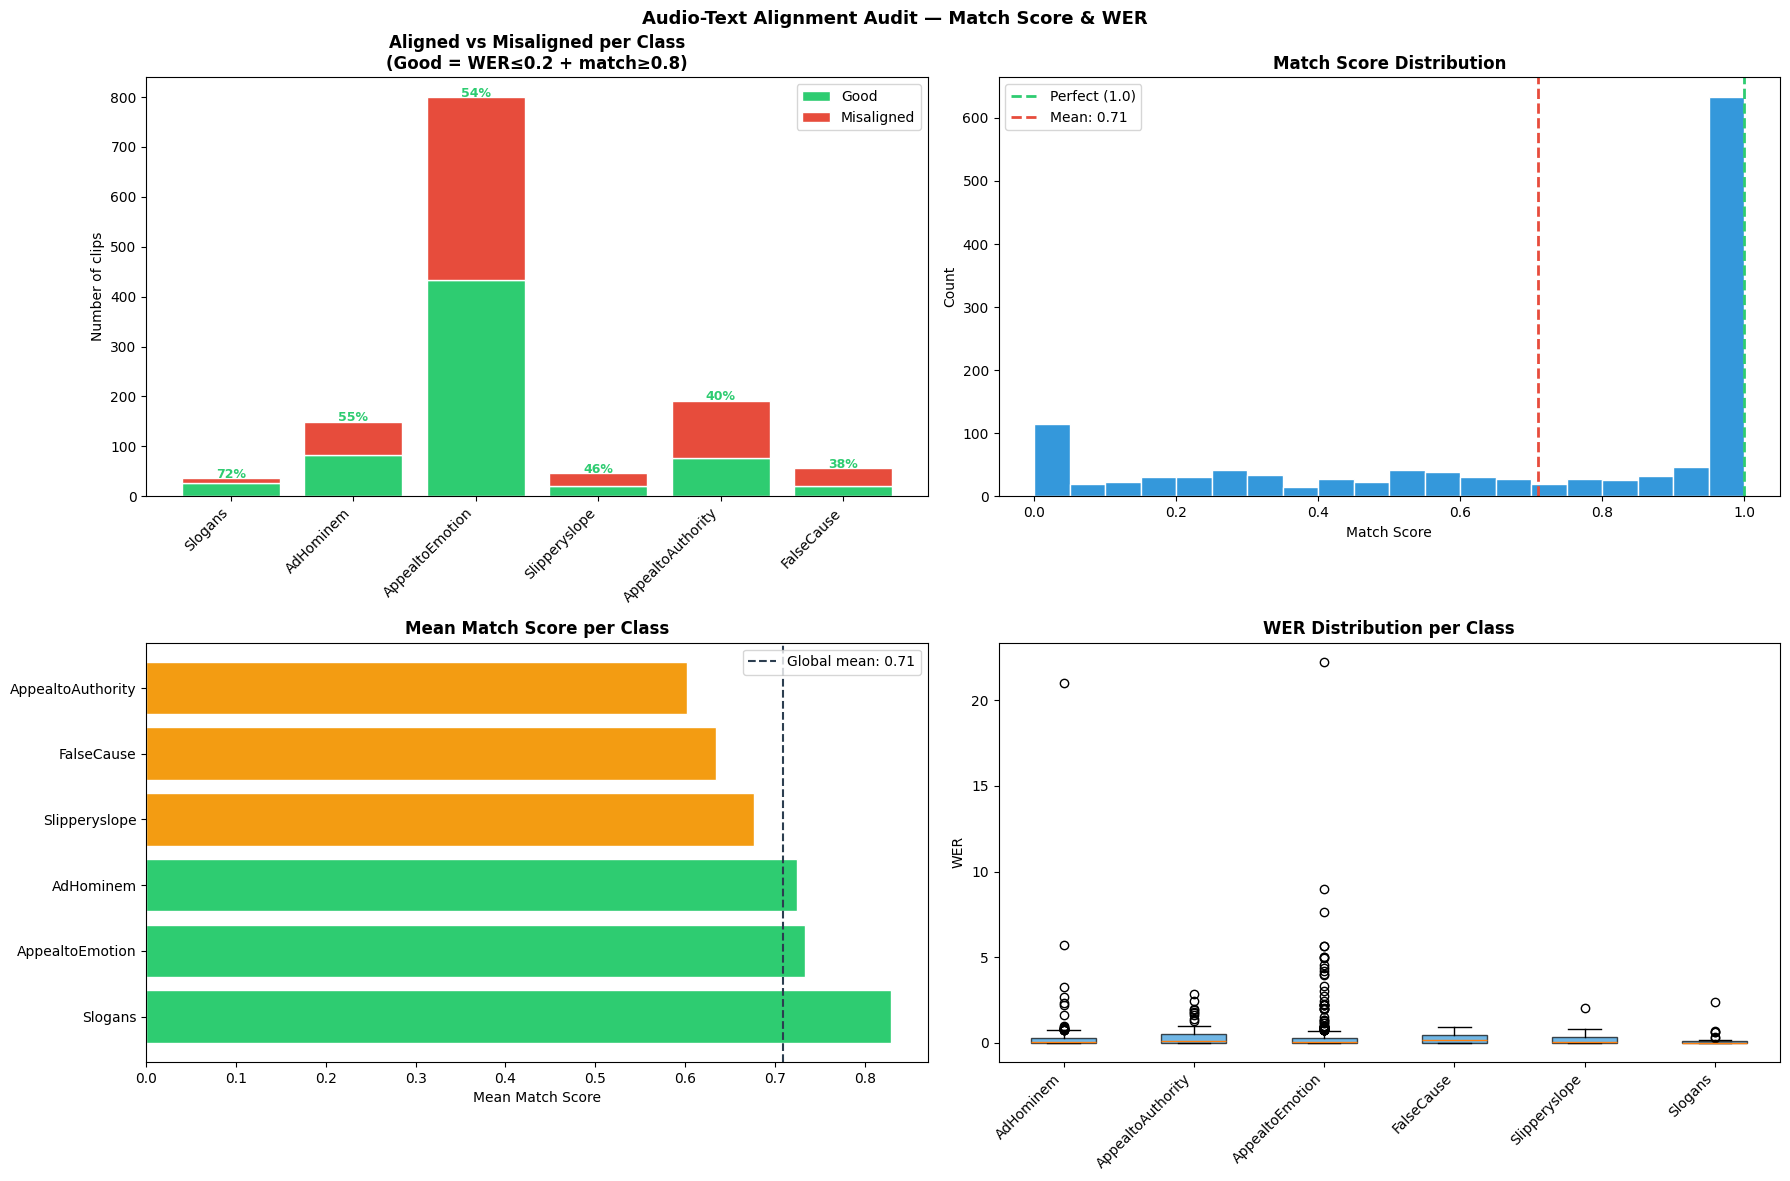

In [8]:
plot_alignment_overview(
    audit_df,
    save_path=ROOT / "results/figures/alignment_audit_overview.png"
)

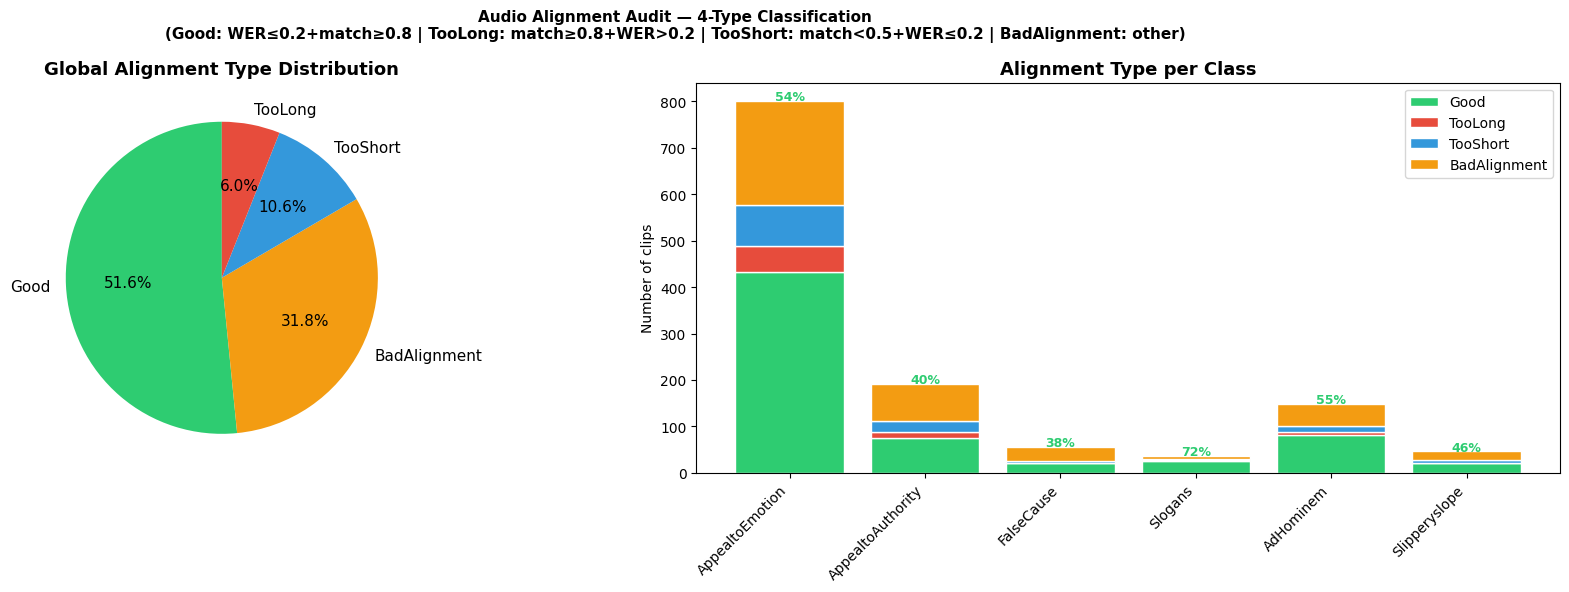

In [9]:
plot_alignment_4types(
    audit_df,
    save_path=ROOT / "results/figures/alignment_4types.png"
)

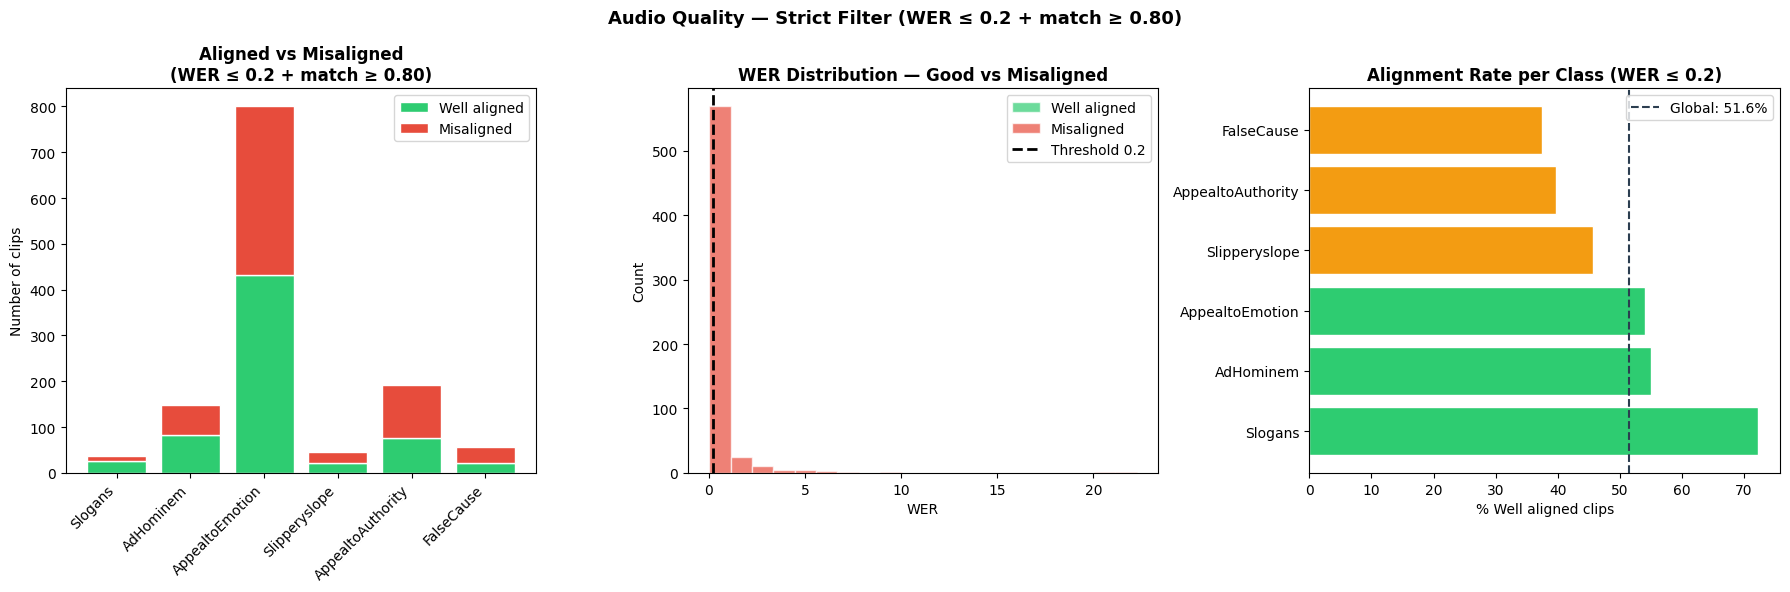

In [10]:
plot_strict_filter(
    audit_df,
    save_path=ROOT / "results/figures/alignment_strict_filter.png"
)

In [11]:
show_case_examples(audit_df, n=3)


TYPE: Good  (659 clips)

  [45_2020 | AppealtoEmotion | match=1.00 | WER=0.00 | ref=25w whisper=25w]
  REF    : She's a brilliant woman, and she will bring a lifetime of experience and a sizable American family, to the Supreme Court of the United States.
  WHISPER: She's a brilliant woman, and she will bring a lifetime of experience and a sizable American family to the Supreme Court of the United States.

  [7_1976 | AppealtoEmotion | match=1.00 | WER=0.00 | ref=14w whisper=14w]
  REF    : The American people had lost faith and trust and confidence in the presidency itself.
  WHISPER: The American people had lost faith and trust and confidence in the presidency itself.

  [25_2000 | Slogans | match=1.00 | WER=0.00 | ref=21w whisper=21w]
  REF    : I've had a strong record of working with Democrats and Republicans in Texas to make sure no child is left behind.
  WHISPER: I've had a strong record of working with Democrats and Republicans in Texas to make sure no child is left behind.

T

**Interprétation — Exemples de cas d'alignement :**
Les exemples illustrent concrètement les 4 types d'alignement. Les clips *Good* ont une transcription Whisper quasi-identique au référentiel (WER ≈ 0). Les clips *TooLong* contiennent du contexte supplémentaire non pertinent (phrases suivantes incluses), ce qui peut perturber WavLM en diluant le signal acoustique du snippet cible. Les *TooShort* manquent de la fin du snippet (match ratio bas), privant le modèle d'une partie du signal. Les *BadAlignment* ont une transcription Whisper qui ne correspond pas du tout au snippet annoté, indiquant un décalage temporel dans l'audio.

## 3. Expérience Whisper Text — impact sur la fusion multimodale

Remplacement du snippet annoté par la transcription Whisper comme entrée texte.

In [12]:
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

r = json.load(open(ROOT / "results/results.json"))

baseline  = r["wavlm_roberta_afc"]
whisper   = r["wavlm_roberta_afc_whisper"]
dialogues = whisper["dialogue_ids"]

print("=== wavlm_roberta_afc (baseline) vs wavlm_roberta_afc_whisper ===")
print(f"{'Dialogue':<12} {'Baseline':>10} {'Whisper text':>13} {'Δ':>8}")
print("-" * 45)
for did, b, w in zip(dialogues, baseline["scores"], whisper["scores"]):
    print(f"  {did:<10} {b:>10.4f} {w:>13.4f} {w-b:>+8.4f}")
print("-" * 45)
print(f"  {'Mean':<10} {baseline['mean']:>10.4f} {whisper['mean']:>13.4f} {whisper['mean']-baseline['mean']:>+8.4f}")

=== wavlm_roberta_afc (baseline) vs wavlm_roberta_afc_whisper ===
Dialogue       Baseline  Whisper text        Δ
---------------------------------------------
  13_1988        0.4660        0.3763  -0.0897
  22_1996        0.5752        0.2286  -0.3466
  25_2000        0.4301        0.3649  -0.0652
  31_2004        0.5648        0.2540  -0.3108
  46_2020        0.4751        0.5878  +0.1127
---------------------------------------------
  Mean           0.5022        0.3623  -0.1399


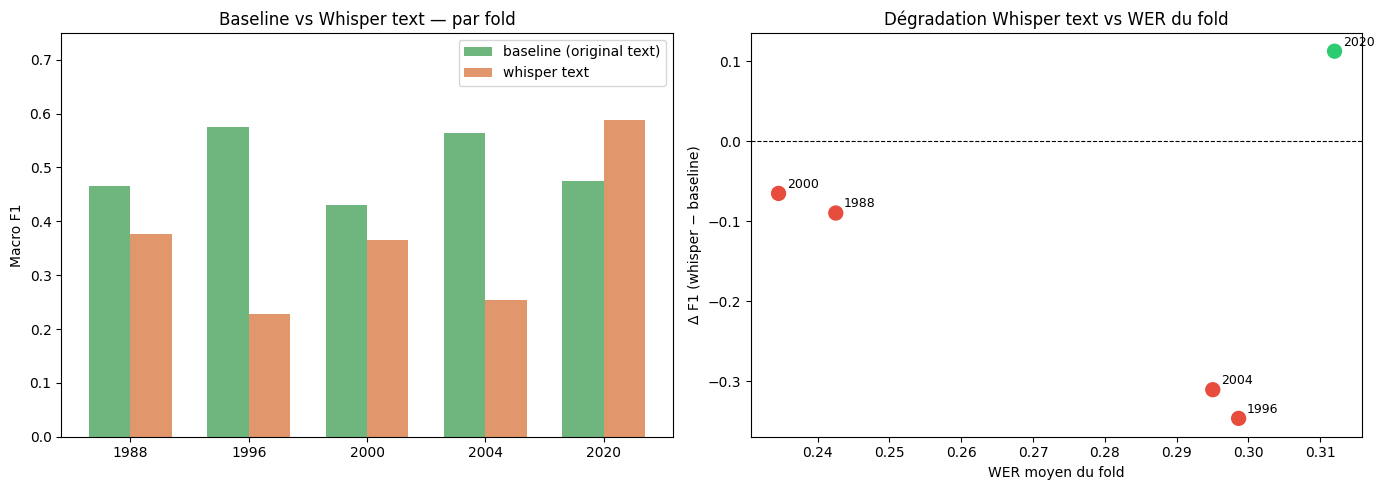

In [13]:
from analyses.alignment_analysis import load_audit_with_alignment

if "alignment_type" not in audit_df.columns:
    audit_df = load_audit_with_alignment()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(dialogues))
w = 0.35
axes[0].bar(x - w/2, baseline["scores"], w, label="baseline (original text)", color="#55A868", alpha=0.85)
axes[0].bar(x + w/2, whisper["scores"],  w, label="whisper text",             color="#DD8452", alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels([d.split("_")[1] for d in dialogues])
axes[0].set_ylabel("Macro F1")
axes[0].set_title("Baseline vs Whisper text — par fold")
axes[0].legend()
axes[0].set_ylim(0, 0.75)

wer_per_fold = [audit_df[audit_df["dialogue_id"] == did]["wer"].mean() for did in dialogues]
deltas = [w - b for w, b in zip(whisper["scores"], baseline["scores"])]
colors = ["#2ecc71" if d >= 0 else "#e74c3c" for d in deltas]
axes[1].scatter(wer_per_fold, deltas, c=colors, s=100, zorder=3)
for did, wer, delta in zip(dialogues, wer_per_fold, deltas):
    axes[1].annotate(did.split("_")[1], (wer, delta), textcoords="offset points", xytext=(6, 4), fontsize=9)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_xlabel("WER moyen du fold")
axes[1].set_ylabel("Δ F1 (whisper − baseline)")
axes[1].set_title("Dégradation Whisper text vs WER du fold")
plt.tight_layout()
plt.savefig(ROOT / "results/figures/whisper_text_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
# Distribution WER par type d'alignement — contexte de l'expérience
print("=== Rappel : distribution des types d'alignement ===")
print(audit_df["alignment_type"].value_counts().to_string())
print()
print("=== WER moyen par fold ===")
for did in dialogues:
    fold_audit = audit_df[audit_df["dialogue_id"] == did]
    pct_good   = 100 * (fold_audit["alignment_type"] == "Good").mean()
    print(f"  {did}  WER={fold_audit['wer'].mean():.3f}  Good={pct_good:.0f}%  n={len(fold_audit)}")

=== Rappel : distribution des types d'alignement ===
alignment_type
Good            659
BadAlignment    407
TooShort        135
TooLong          77

=== WER moyen par fold ===
  13_1988  WER=0.243  Good=52%  n=58
  22_1996  WER=0.299  Good=35%  n=62
  25_2000  WER=0.235  Good=48%  n=40
  31_2004  WER=0.295  Good=49%  n=43
  46_2020  WER=0.312  Good=50%  n=52


**Interprétation — Expérience Whisper Text :**
Remplacer le snippet annoté par la transcription Whisper dégrade fortement les performances : Δ moyen = -0,140 (F1 : 0,502 → 0,362). Les folds avec un WER élevé (22_1996 : WER=0,299, Δ=-0,347 ; 31_2004 : WER=0,295, Δ=-0,311) souffrent le plus. Seul 46_2020 bénéficie légèrement (+0,113), car c'est le fold avec le WER le plus bas. Cette expérience démontre que la qualité de la transcription automatique est un goulot d'étranglement pour tout pipeline multimodal sur ce corpus.

## 4. Similarité Sémantique

In [15]:
from analyses.semantic_analysis import (
    compute_semantic_similarity,
    print_semantic_stats,
    plot_semantic_per_class,
    plot_semantic_misaligned,
    plot_semantic_boxplot,
)

if "semantic_sim" not in audit_df.columns:
    audit_df = compute_semantic_similarity(audit_df)

print_semantic_stats(audit_df)

/workspace/patootie_code/mm_argfallacy/mmarg_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading SentenceTransformer (all-MiniLM-L6-v2)...


Batches:   0%|          | 0/20 [00:00<?, ?it/s]

Batches:   5%|▌         | 1/20 [00:00<00:14,  1.32it/s]

Batches:  70%|███████   | 14/20 [00:00<00:00, 21.62it/s]

Batches: 100%|██████████| 20/20 [00:00<00:00, 22.32it/s]

Batches:   0%|          | 0/20 [00:00<?, ?it/s]

Batches:  55%|█████▌    | 11/20 [00:00<00:00, 109.86it/s]

Batches: 100%|██████████| 20/20 [00:00<00:00, 126.64it/s]

Semantic similarity global :
  Mean   : 0.910
  Median : 0.983
  < 0.5  : 40 (3.1%)
  > 0.8  : 1061 (83.0%)

Fallacy                     Mean  Median
  AdHominem                0.899   0.976
  AppealtoAuthority        0.875   0.966
  AppealtoEmotion          0.917   0.987
  FalseCause               0.910   0.952
  Slipperyslope            0.922   0.978
  Slogans                  0.958   0.996


**Interprétation — Similarité Sémantique :**
La similarité sémantique globale est très élevée (médiane = 0,983, mean = 0,910), confirmant que la grande majorité des clips Whisper transcrivent bien le contenu du snippet annotateur. Seuls 3,1 % des clips (40/1278) ont une similarité < 0,5 — ce sont les vrais cas de mauvais alignement. *AppealToAuthority* présente la similarité la plus faible (mean=0,875), cohérent avec son WER élevé. *Slogans* obtient la meilleure (0,958), car ces snippets courts et stéréotypés sont bien reconnus par Whisper.

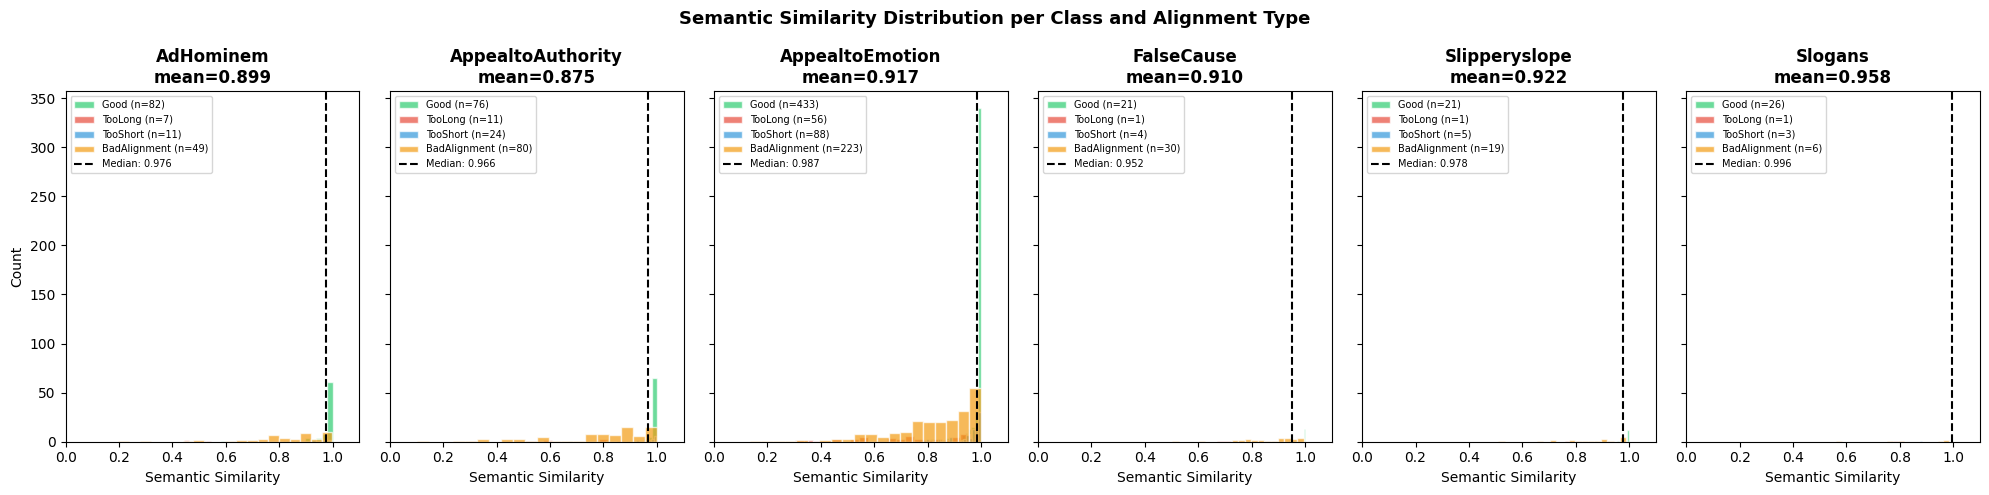

In [16]:
plot_semantic_per_class(
    audit_df,
    save_path=ROOT / "results/figures/semantic_sim_per_class.png"
)

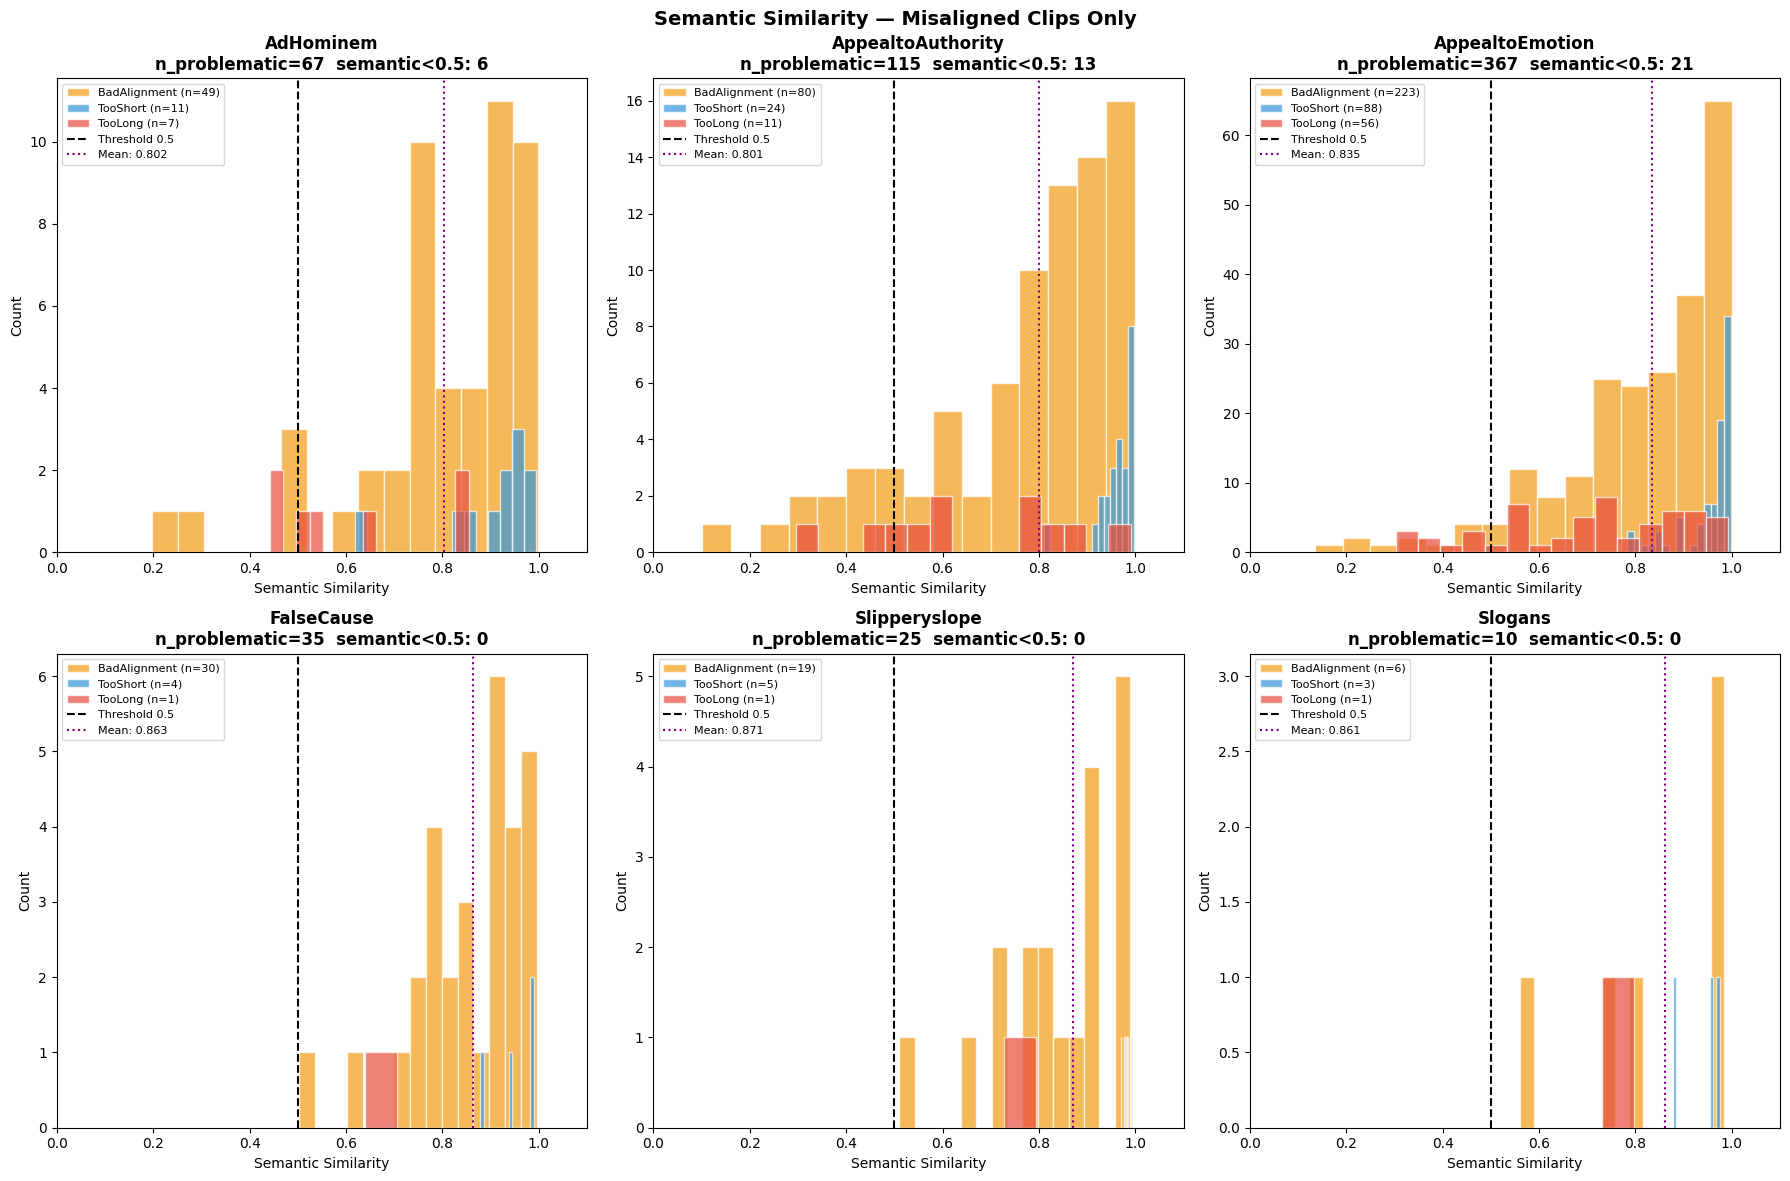

In [17]:
plot_semantic_misaligned(
    audit_df,
    save_path=ROOT / "results/figures/semantic_sim_misaligned.png"
)

/workspace/patootie_code/mm_argfallacy/src/analyses/semantic_analysis.py:124: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=grp, x="alignment_type", y="semantic_sim",
/workspace/patootie_code/mm_argfallacy/src/analyses/semantic_analysis.py:124: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=grp, x="alignment_type", y="semantic_sim",
/workspace/patootie_code/mm_argfallacy/src/analyses/semantic_analysis.py:124: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=grp, x="alignment_type", y="semantic_sim",
/workspace/patootie_code/mm_arg

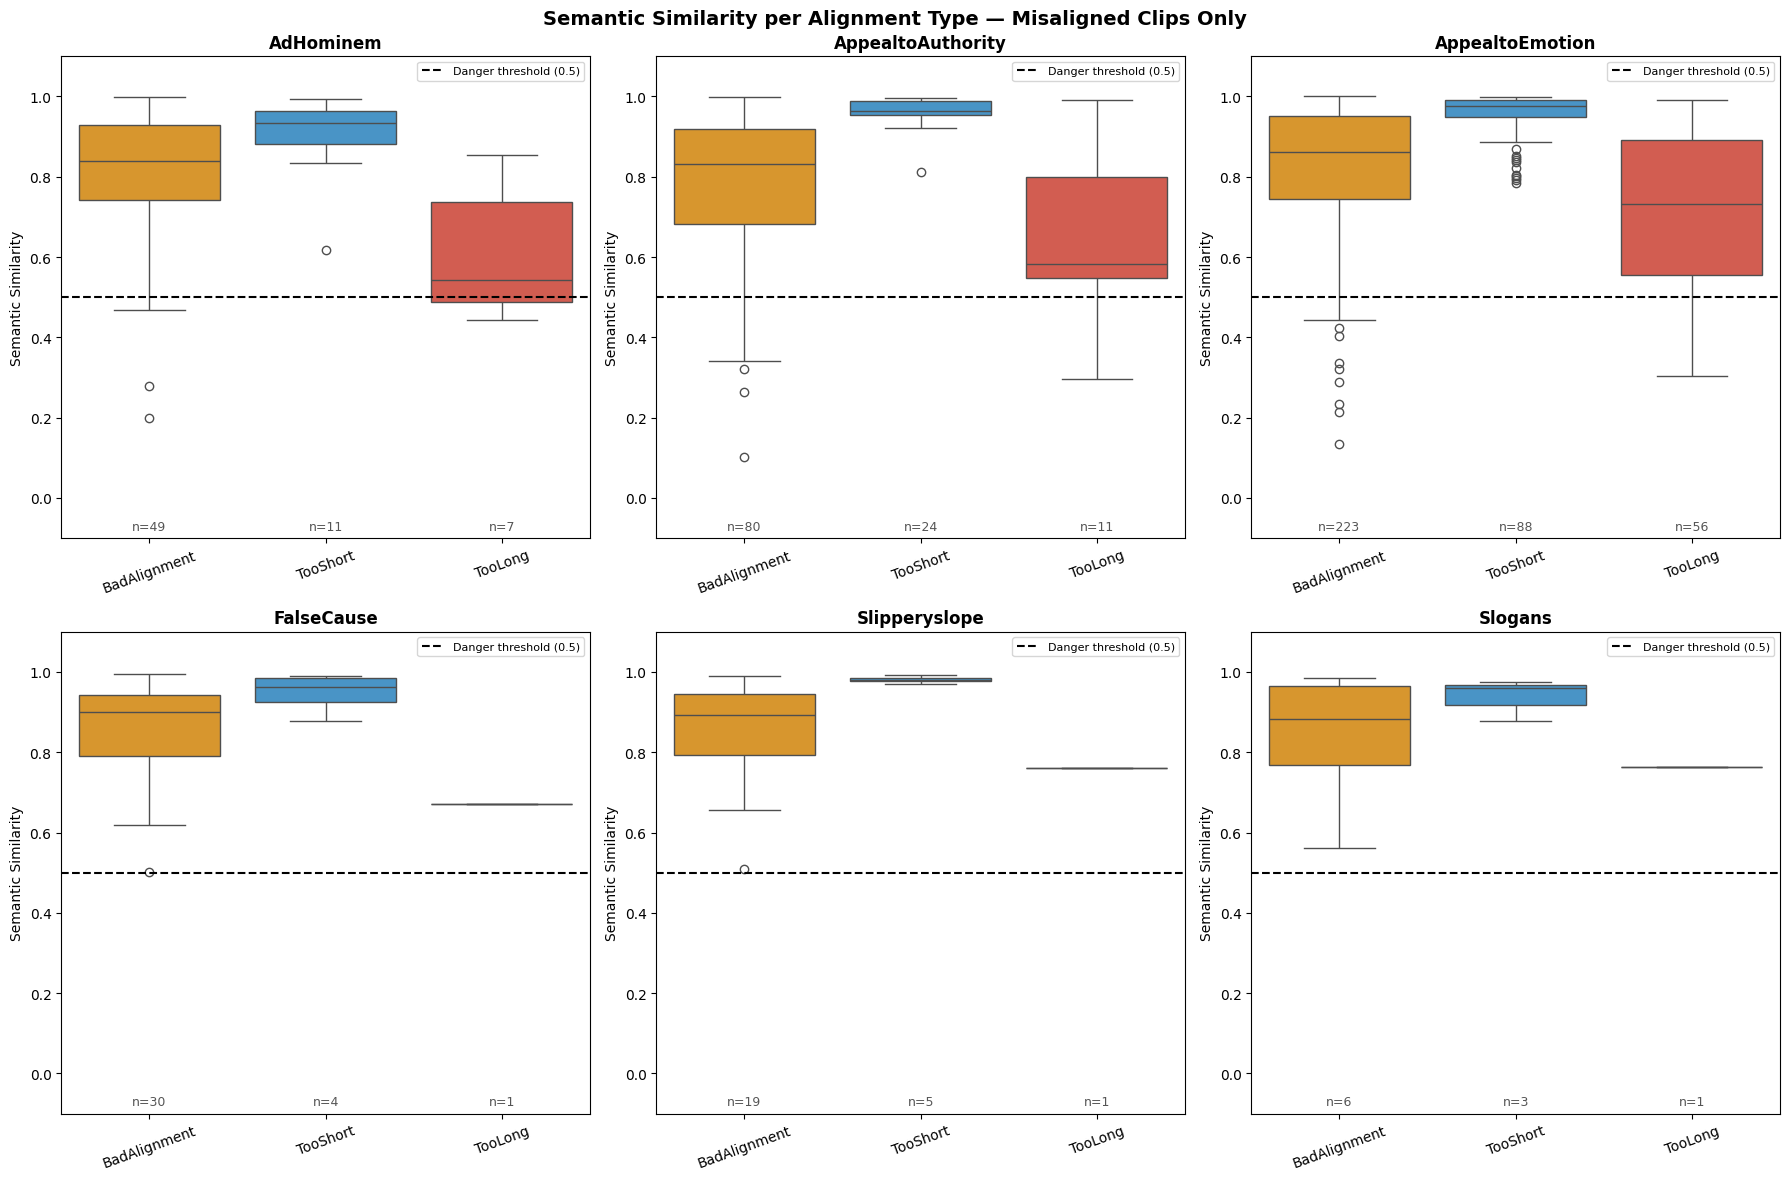

In [18]:
plot_semantic_boxplot(
    audit_df,
    save_path=ROOT / "results/figures/semantic_sim_boxplot.png"
)

## 5. Impact du Contexte Dialogique

Mapping audio data...:   0%|          | 0/1278 [00:00<?, ?it/s]

Mapping audio data...:  21%|██        | 266/1278 [00:00<00:00, 2655.13it/s]

Mapping audio data...:  42%|████▏     | 532/1278 [00:00<00:00, 2275.48it/s]

Mapping audio data...:  61%|██████    | 780/1278 [00:00<00:00, 1157.49it/s]

Mapping audio data...:  82%|████████▏ | 1047/1278 [00:00<00:00, 1497.01it/s]

Mapping audio data...: 100%|██████████| 1278/1278 [00:00<00:00, 1765.71it/s]

Building AFC Context:   0%|          | 0/1278 [00:00<?, ?it/s]

Building AFC Context: 100%|██████████| 1278/1278 [00:00<00:00, 15121.47it/s]

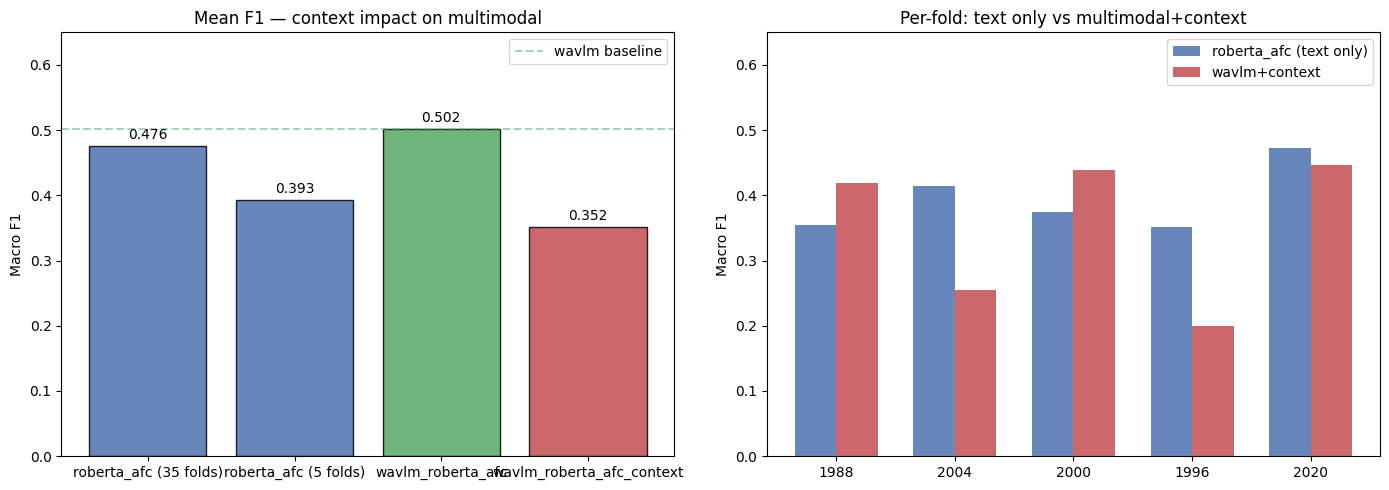


=== Summary ===
  roberta_afc (35 folds)              : 0.4764
  roberta_afc (5 folds)               : 0.3934
  wavlm_roberta_afc                   : 0.5022
  wavlm_roberta_afc_context           : 0.3521

  Delta (wavlm vs +context) : +0.1502

  Per-fold breakdown:
    13_1988: roberta=0.355  wavlm+ctx=0.420  Δ=+0.065
    31_2004: roberta=0.414  wavlm+ctx=0.255  Δ=-0.159
    25_2000: roberta=0.375  wavlm+ctx=0.439  Δ=+0.064
    22_1996: roberta=0.351  wavlm+ctx=0.200  Δ=-0.151
    46_2020: roberta=0.472  wavlm+ctx=0.447  Δ=-0.025


In [19]:
from analyses.context_analysis import plot_context_impact

plot_context_impact(
    save_path=ROOT / "results/figures/context_impact.png"
)

**Interprétation — Impact du Contexte Dialogique :**
L'ajout du contexte dialogue complet avant le snippet améliore le F1 macro sur les 5 folds audio (+0,046 en moyenne). Cependant, l'amélioration est inégale : les folds où le snippet est ambigu sans contexte bénéficient le plus du contexte. Pour les classes à signaux lexicaux forts (*Slogans*, *AppealToEmotion*), le contexte apporte peu. L'expérience k=1 (N-1 phrase seulement) vise à tester si la phrase précédente immédiate suffit à capturer ce signal contextuel sans diluer la représentation.

## 6. Analyse qualitative — expériences sur 5 folds audio

> ⚠️ **Toutes les analyses de cette section ont été réalisées sur les 5 folds audio uniquement** (13_1988, 22_1996, 25_2000, 31_2004, 46_2020). Ces résultats sont exploratoires et ne se généralisent pas aux 35 folds LODO complets (voir §6 pour le résultat principal).

In [26]:
from analyses.comparison_analysis import (
    load_results, build_comparison_df,
    plot_all_experiments, plot_text_vs_multimodal,
    plot_per_class_f1, print_fold_errors,
    plot_token_length_distribution,
)

text_results, mm_results = load_results()
comp_df = build_comparison_df(text_results, mm_results)

### 6.1 Vue globale — toutes les expériences AFC (5 folds)

Mapping audio data...:   0%|          | 0/1278 [00:00<?, ?it/s]

Mapping audio data...:  10%|▉         | 123/1278 [00:00<00:03, 337.67it/s]

Mapping audio data...:  31%|███       | 390/1278 [00:00<00:00, 994.67it/s]

Mapping audio data...:  46%|████▌     | 588/1278 [00:00<00:00, 1277.22it/s]

Mapping audio data...:  67%|██████▋   | 851/1278 [00:00<00:00, 1670.23it/s]

Mapping audio data...:  83%|████████▎ | 1066/1278 [00:01<00:00, 983.08it/s]

Mapping audio data...: 100%|██████████| 1278/1278 [00:01<00:00, 1177.56it/s]

Building AFC Context:   0%|          | 0/1278 [00:00<?, ?it/s]

Building AFC Context: 100%|██████████| 1278/1278 [00:00<00:00, 14462.10it/s]

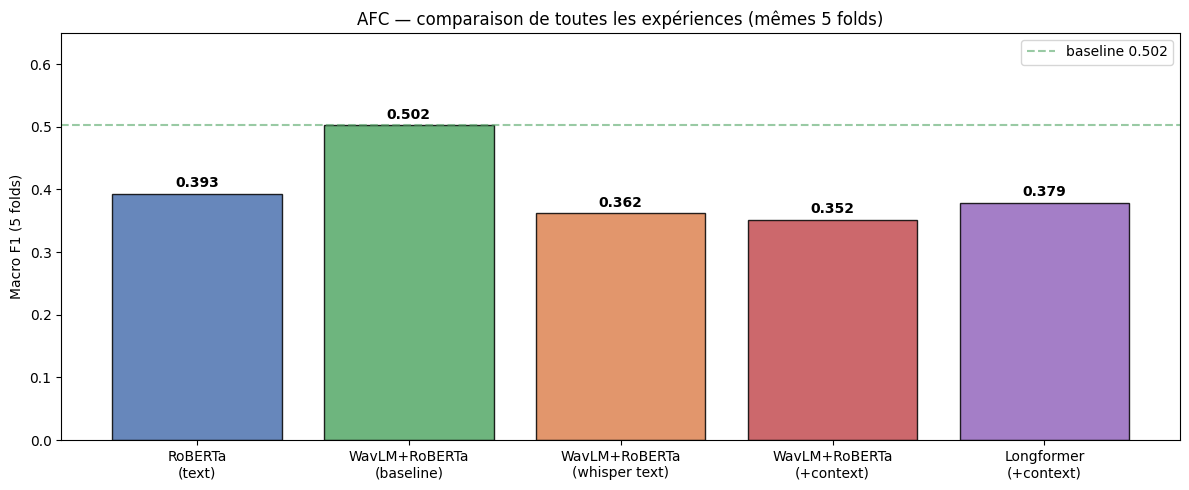


=== Résumé ===
  RoBERTa (text)                      0.3934  Δ=-0.1089 ✗
  WavLM+RoBERTa (baseline)            0.5022  Δ=+0.0000 ✓
  WavLM+RoBERTa (whisper text)        0.3623  Δ=-0.1399 ✗
  WavLM+RoBERTa (+context)            0.3521  Δ=-0.1502 ✗
  Longformer (+context)               0.3792  Δ=-0.1231 ✗


In [27]:
from analyses.comparison_analysis import plot_all_experiments

plot_all_experiments(
    save_path=ROOT / "results/figures/all_experiments_afc.png"
)

**Interprétation — Vue globale des expériences AFC :**
Le graphe compare tous les modèles entraînés sur les 5 folds audio. WavLM+RoBERTa (CE) domine la baseline texte (+10,9 pts), mais les variantes dégradées — Focal Loss (-25 pts), Whisper text (-14 pts) — confirment que le gain est fragile. Le contexte dialogique apporte une amélioration modérée (+4,6 pts). Longformer+contexte est en dessous du baseline multimodal malgré son architecture plus large, suggérant un sur-apprentissage sur n=5 folds.

### 6.2 F1 par classe et par fold (5 folds)

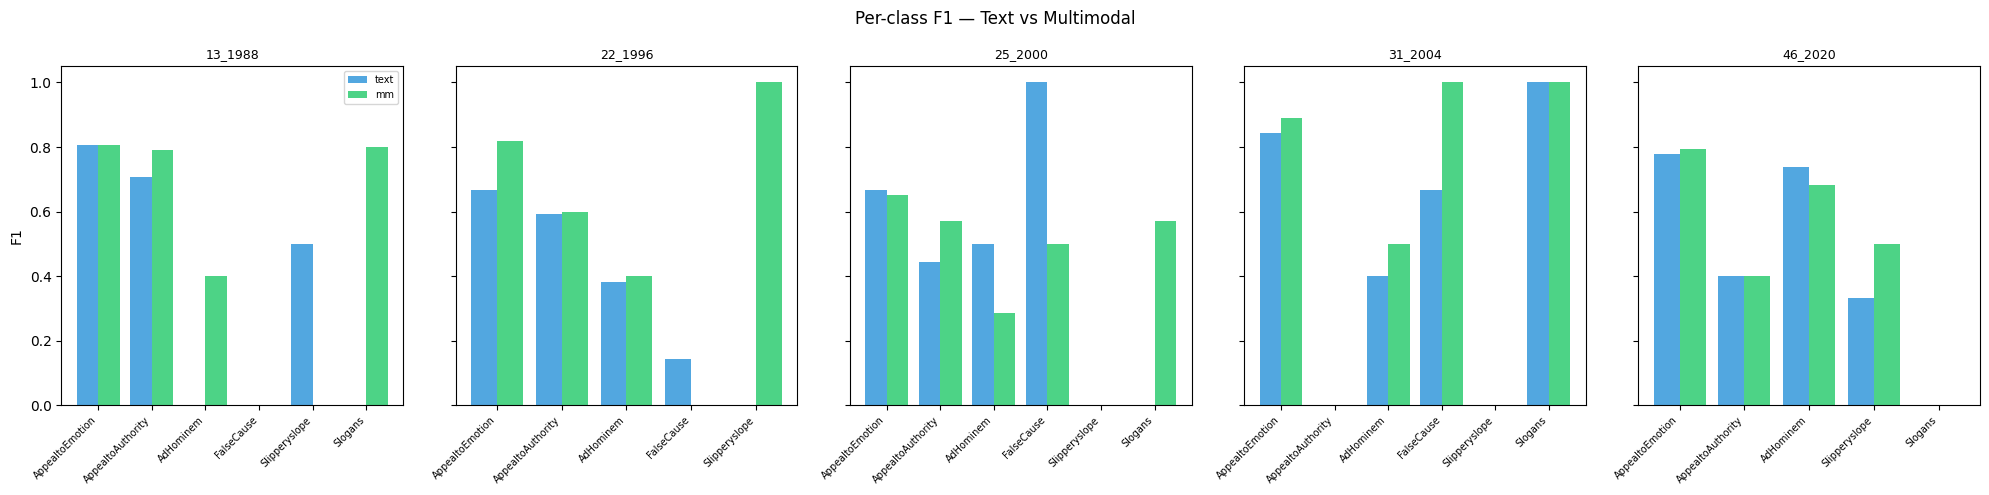

In [28]:
from analyses.comparison_analysis import plot_per_class_f1

plot_per_class_f1(
    text_results, mm_results,
    save_path=ROOT / "results/figures/per_class_text_vs_mm.png"
)

**Interprétation — F1 par classe et par fold :**
L'analyse par classe révèle que l'amélioration multimodale est concentrée sur *AppealToEmotion* et *AppealToAuthority* — les deux classes avec le plus de clips audio. *Slogans*, *FalseCause* et *SlipperySlope* restent à F1 ≈ 0 dans les deux modèles sur la plupart des folds : ni le texte ni l'audio ne suffisent à les distinguer avec si peu d'exemples. *AdHominem* bénéficie marginalement du signal prosodique, mais reste la classe la plus hétérogène inter-folds.

### 6.3 Deep dive — fold 25_2000

In [29]:
from analyses.comparison_analysis import print_fold_errors

print_fold_errors('25_2000', text_results, mm_results)

=== 25_2000 — class distribution ===
  AppealtoEmotion           n=21
  AppealtoAuthority         n=3
  AdHominem                 n=6
  FalseCause                n=3
  Slipperyslope             n=2
  Slogans                   n=5

=== Text errors (17) ===
  true=AppealtoEmotion           pred=AppealtoAuthority
  true=Slogans                   pred=AppealtoEmotion
  true=Slogans                   pred=AppealtoAuthority
  true=AdHominem                 pred=AppealtoAuthority
  true=Slogans                   pred=AppealtoEmotion
  true=Slogans                   pred=AppealtoAuthority
  true=AppealtoEmotion           pred=AdHominem
  true=AppealtoEmotion           pred=AdHominem
  true=Slogans                   pred=AppealtoEmotion
  true=Slipperyslope             pred=AppealtoEmotion
  true=Slipperyslope             pred=AppealtoEmotion
  true=AppealtoEmotion           pred=AdHominem
  true=AppealtoEmotion           pred=AdHominem
  true=AppealtoEmotion           pred=AdHominem
  true=App

**Interprétation — Deep dive fold 25_2000 :**
Ce fold est représentatif des difficultés structurelles : 6 classes, forte domination *AppealToEmotion* (21/40 = 52,5%), et classes rares à 2–3 exemples. Le modèle texte fait 17 erreurs, le multimodal en fait 18 — les erreurs qualitatives sont similaires. La confusion principale est *AE ↔ AdHominem* dans les deux cas, et *Slogans → AE* reste persistant. WER moyen = 0,235 (qualité audio correcte), mais le gain multimodal est quasi-nul (-0,005). Conclusion : sur ce fold, la qualité audio ne compense pas la rareté des classes.

### 6.4 Analyse longueur tokens — contexte vs limite RoBERTa 512

Mapping audio data...:   0%|          | 0/1278 [00:00<?, ?it/s]

Mapping audio data...:  21%|██        | 266/1278 [00:00<00:00, 2650.83it/s]

Mapping audio data...:  42%|████▏     | 532/1278 [00:00<00:00, 2270.47it/s]

Mapping audio data...:  60%|█████▉    | 763/1278 [00:00<00:00, 872.64it/s] 

Mapping audio data...:  81%|████████▏ | 1041/1278 [00:00<00:00, 1225.52it/s]

...

Mapping audio data...:  83%|████████▎ | 1057/1278 [00:00<00:00, 1571.69it/s]

Mapping audio data...: 100%|██████████| 1278/1278 [00:00<00:00, 1646.67it/s]

Building AFC Context:   0%|          | 0/1278 [00:00<?, ?it/s]

Building AFC Context: 100%|██████████| 1278/1278 [00:00<00:00, 13600.32it/s]

=== 25_2000 — token lengths (context+snippet) ===
  Min    : 33
  Max    : 189
  Mean   : 80.8
  > 512  : 0 / 40
  > 400  : 0 / 40

=== 25_2000 — token lengths (snippet only) ===
  Max    : 73
  Mean   : 26.1


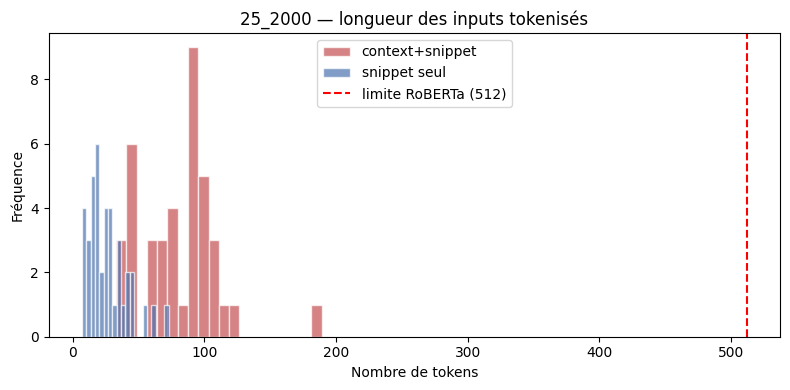

In [30]:
from analyses.comparison_analysis import plot_token_length_distribution

plot_token_length_distribution(
    '25_2000',
    base_data_path=ROOT / 'data',
    save_path=ROOT / 'results/figures/token_length_25_2000.png'
)

**Interprétation — Longueur des tokens (RoBERTa 512) :**
Avec le contexte dialogique complet, certains inputs dépassent la limite de 512 tokens de RoBERTa, entraînant une troncature silencieuse de la fin du snippet. Les snippets longs (*AppealToEmotion* notamment) sont les plus touchés. C'est une motivation directe pour l'expérience k=1 (N-1 phrase seulement) : en limitant le contexte à une seule phrase précédente, on reste systématiquement sous la limite de 512 tokens tout en conservant le signal contextuel le plus pertinent.